In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n=10**-3/4
n3=0.9*10**-3
width = 4000
width2 = 1000
Lx=10**5
x = np.arange(0,1024)*Lx/1024
eta1 = -20 / np.cosh((x - 0.2*Lx) / width)**2
eta1a = -20 / np.cosh((x - 0.205*Lx) / width)**2
dt=2500
eta2 = -20 / np.cosh((x - 0.5*Lx) / width)**2
eta2a = -20 / np.cosh((x - 0.505*Lx) / width)**2
eta3 = -20 / np.cosh((x - 0.8*Lx) / width)**2
eta3a = -20 / np.cosh((x - 0.805*Lx) / width)**2


eta1_asymm = -20 / np.cosh((x - 0.2*Lx) / width)**2
eta1_asymm[205:405] =(-20 / np.cosh((x - 0.2*Lx) / width2)**2)[205:405]

eta1a_asymm = -20 / np.cosh((x - 0.205*Lx) / width)**2
eta1a_asymm[210:410] = (-20 / np.cosh((x - 0.205*Lx) / width2)**2)[210:410]

dt=2500
eta2_asymm = -20*(np.cosh(n)**2/np.cosh(n*(x-0.5*Lx))**2)
eta2_asymm[512:712] = -20*(np.cosh(n3)**2/np.cosh(n3*(x-0.5*Lx))**2)[512:712]

eta2a_asymm = -20*(np.cosh(n)**2/np.cosh(n*(x-0.505*Lx))**2)
eta2a_asymm[517:717] =-20*(np.cosh(n3)**2/np.cosh(n3*(x-0.505*Lx))**2)[517:717]

eta3_asymm = -20*(np.cosh(n)**2/np.cosh(n*(x-0.8*Lx))**2)
eta3_asymm[819:] = -20*(np.cosh(n3)**2/np.cosh(n3*(x-0.8*Lx))**2)[819:]

eta3a_asymm = -20*(np.cosh(n)**2/np.cosh(n*(x-0.805*Lx))**2)
eta3a_asymm[824:] = -20*(np.cosh(n3)**2/np.cosh(n3*(x-0.805*Lx))**2)[824:]

In [3]:
detadt1 = (eta1a-eta1)/dt
detadt2 = (eta2a-eta2)/dt
detadt3 = (eta3a-eta3)/dt

detadt1_asymm = (eta1a_asymm-eta1_asymm)/dt
detadt2_asymm = (eta2a_asymm-eta2_asymm)/dt
detadt2_asymm[517] = detadt1_asymm.min()
detadt3_asymm = (eta3a_asymm-eta3_asymm)/dt
detadt3_asymm[824] = detadt1_asymm.min()

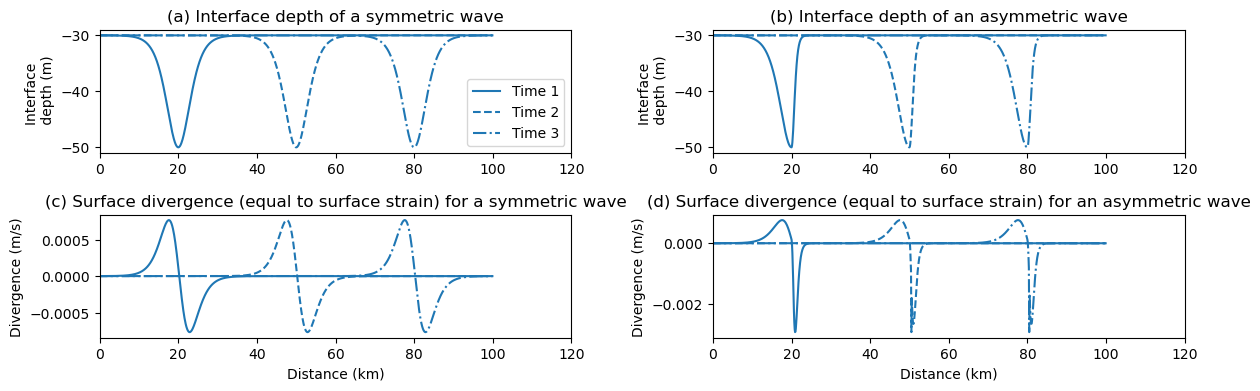

In [4]:
plt.figure(figsize=(14,4))
plt.subplot(221)
plt.plot(x/1000,eta1-30,label='Time 1')
plt.plot(x/1000,eta2-30,color='tab:blue',linestyle='--',label='Time 2')
plt.plot(x/1000,eta3-30,color='tab:blue',linestyle='-.',label='Time 3')
plt.ylabel('Interface \n depth (m)')
plt.title('(a) Interface depth of a symmetric wave')
plt.legend(loc ='lower right')
plt.xlim(0,120)

plt.subplot(222)
plt.plot(x/1000,eta1_asymm-30)
plt.plot(x/1000,eta2_asymm-30,color='tab:blue',linestyle='--')
plt.plot(x/1000,eta3_asymm-30,color='tab:blue',linestyle='-.')
plt.ylabel('Interface \n depth (m)')

plt.title('(b) Interface depth of an asymmetric wave')
plt.xlim(0,120)

plt.subplot(223)
plt.plot(x/1000,detadt1)
plt.plot(x/1000,detadt2,color='tab:blue',linestyle='--')
plt.plot(x/1000,detadt3,color='tab:blue',linestyle='-.')
plt.title('(c) Surface divergence (equal to surface strain) for a symmetric wave')
plt.ylabel('Divergence (m/s)')
plt.xlabel('Distance (km)')
plt.xlim(0,120)

plt.subplot(224)
plt.plot(x/1000,detadt1_asymm)
plt.plot(x/1000,detadt2_asymm,color='tab:blue',linestyle='--')
plt.plot(x/1000,detadt3_asymm,color='tab:blue',linestyle='-.')
plt.title('(d) Surface divergence (equal to surface strain) for an asymmetric wave')
plt.ylabel('Divergence (m/s)')
plt.xlabel('Distance (km)')
plt.xlim(0,120)

plt.subplots_adjust(wspace = 0.3, hspace = 0.5)
plt.savefig('wave_cartoon.png')